## 1. Data cleaning

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load metadata
metadata = pd.read_csv('../data/raw/archelect_search.csv', low_memory=False)
metadata.shape

(33030, 42)

In [65]:
metadata.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='str')

In [66]:
print(metadata.head(5).to_string())

                               id        date                                                          subject                                                                                                           title contexte-election  contexte-tour   cote departement departement-nom departement-insee identifiant de circonscription                                                                                                                                                                                                                         images                                                                                                         pdf                                                                                                          ocr_url titulaire-nom titulaire-prenom titulaire-sexe  titulaire-age titulaire-age-calcule titulaire-age-tranche   titulaire-profession titulaire-mandat-en-cours titulaire-mandat-passe titulaire-associations titulaire-autres

In [67]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 33030 entries, 0 to 33029
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id                              33030 non-null  str  
 1   date                            33030 non-null  str  
 2   subject                         33030 non-null  str  
 3   title                           33030 non-null  str  
 4   contexte-election               33030 non-null  str  
 5   contexte-tour                   33030 non-null  int64
 6   cote                            33030 non-null  str  
 7   departement                     32688 non-null  str  
 8   departement-nom                 32669 non-null  str  
 9   departement-insee               32666 non-null  str  
 10  identifiant de circonscription  32136 non-null  str  
 11  images                          33003 non-null  str  
 12  pdf                             31855 non-null  str  
 13  ocr_url     

In [68]:
# missing values
metadata.isnull().sum().sort_values(ascending=False)

pdf                               1175
suppleant-profession              1105
suppleant-decorations             1102
suppleant-liste                   1101
suppleant-associations            1101
suppleant-mandat-en-cours         1100
suppleant-nom                     1100
suppleant-prenom                  1100
suppleant-sexe                    1100
suppleant-age                     1100
suppleant-age-calcule             1100
suppleant-age-tranche             1100
suppleant-autres-statuts          1100
suppleant-soutien                 1100
suppleant-mandat-passe            1100
identifiant de circonscription     894
departement-insee                  364
departement-nom                    361
departement                        342
images                              27
titulaire-profession                16
titulaire-associations               2
titulaire-soutien                    0
titulaire-decorations                0
titulaire-liste                      0
id                       

In [69]:
print('Total missing values:', metadata.isna().sum().sum())

Total missing values: 18590


In [70]:
# unzip text files
import zipfile
import os

base_path = "../data/raw/text_files"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".zip"):

            zip_path = os.path.join(root, file)

            # create extraction folder using zip name
            extract_folder = os.path.join(root, os.path.splitext(file)[0])

            # skip if already extracted
            if os.path.exists(extract_folder) and len(os.listdir(extract_folder)) > 0:
                print(f"Skipping already extracted: {zip_path}")
                continue

            os.makedirs(extract_folder, exist_ok=True)

            try:
                with zipfile.ZipFile(zip_path, "r") as zip_ref:
                    zip_ref.extractall(extract_folder)

                print(f"Extracted: {zip_path}")

            except zipfile.BadZipFile:
                print(f"Bad zip file: {zip_path}")

print("Unzipping complete.")

Skipping already extracted: ../data/raw/text_files/1988/legislatives.zip
Skipping already extracted: ../data/raw/text_files/1981/legislatives.zip
Skipping already extracted: ../data/raw/text_files/1993/presidentielle.zip
Skipping already extracted: ../data/raw/text_files/1993/legislatives.zip
Unzipping complete.


In [71]:
# load text files

base_path = "../data/raw/text_files"
all_txt_files = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".txt"):
            all_txt_files.append(os.path.join(root, file))

print("Number of text files:", len(all_txt_files))
print("Example files:", all_txt_files[:5])


Number of text files: 12746
Example files: ['../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL175_L_1988_06_037_03_1_PF_03.txt', '../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL177_L_1988_06_078_05_1_PF_01.txt', '../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL175_L_1988_06_049_06_1_PF_04.txt', '../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL175_L_1988_06_054_06_1_PF_05.txt', '../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL177_L_1988_06_094_05_1_PF_06.txt']


In [72]:
# show some samples
import random
print(random.sample(all_txt_files, 10))

['../data/raw/text_files/1981/legislatives/text_files/1981/legislatives/EL137_L_1981_06_076_06_2_PF_01.txt', '../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL176_L_1988_06_069_13_1_PF_05.txt', '../data/raw/text_files/1981/legislatives/text_files/1981/legislatives/EL134_L_1981_06_031_02_1_PF_05.txt', '../data/raw/text_files/1981/legislatives/text_files/1981/legislatives/EL137_L_1981_06_077_01_2_PF_02.txt', '../data/raw/text_files/1988/legislatives/text_files/1988/legislatives/EL175_L_1988_06_031_02_1_PF_01.txt', '../data/raw/text_files/1993/legislatives/text_files/1993/legislatives/EL196_L_1993_03_076_02_1_PF_01.txt', '../data/raw/text_files/1993/legislatives/text_files/1993/legislatives/EL198_L_1993_03_093_06_1_PF_02.txt', '../data/raw/text_files/1993/legislatives/text_files/1993/legislatives/EL192_L_1993_03_056_05_1_PF_04.txt', '../data/raw/text_files/1993/legislatives/text_files/1993/legislatives/EL189_L_1993_03_014_01_2_PF_01.txt', '../data/raw/text_files/198

In [73]:
# create dict text files
text_dict = {}

for file_path in all_txt_files:
    file_name = os.path.basename(file_path)
    file_id = file_name.replace(".txt", "")
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        text_dict[file_id] = f.read()

print("Texts loaded:", len(text_dict))

Texts loaded: 12746


In [74]:
# show sample of ID's text
for file_id, text in random.sample(list(text_dict.items()), 5):
    print("ID:", file_id)
    print("Preview:", text[:100])  # first 100 characters
    print("-" * 50)

ID: EL135_L_1981_06_061_01_1_PF_01
Preview: Sciences Po / fonds CEVIPOF
Pierre BOURBAN
51 ans, né à La Sauvagère, marié, père de six enfants. Ag
--------------------------------------------------
ID: EL192_L_1993_03_044_02_1_PF_09
Preview: Sciences Po / fonds CEVIPOF
RÉPUBLIQUE FRANÇAISE - ÉLECTIONS LÉGISLATIVES DES 21 ET 28 MARS 1993
Imp
--------------------------------------------------
ID: EL198_L_1993_03_093_11_1_PF_13
Preview: Sciences Po / fonds CEVIPOF
RÉPUBLIQUE FRANÇAISE - ÉLECTIONS LÉGISLATIVES DES 21 ET 28 MARS 1993
Imp
--------------------------------------------------
ID: EL174_L_1988_06_018_01_1_PF_03
Preview: 1re circonscription
Département du Cher Elections législatives - Juin 1988
République française
J.F.
--------------------------------------------------
ID: EL177_L_1988_06_075_07_1_PF_09
Preview: Sciences Po / fonds CEVIPOF
POUR UNE POLITIQUE HUMANISTE.
L'Humanisme intervient aujourd'hui dans la
--------------------------------------------------


In [75]:
# join metadata and text corresponding to using ID
metadata["text"] = metadata["id"].map(text_dict)

print("Missing texts:", metadata["text"].isna().sum())

Missing texts: 20533


In [76]:
metadata.shape

(33030, 43)

In [77]:
# select only text exist
df_merged = metadata[~metadata["text"].isna()].copy()
df_merged.shape

(12497, 43)

In [78]:
print(df_merged['text'].head())

19480    ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e C...
19481    Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...
19482    Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
19483    REPUBLIQUE FRANÇAISE - ELECTIONS LEGISLATIVES ...
19484    REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...
Name: text, dtype: str


In [79]:
print(df_merged.iloc[0]['text'])

ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e CIRCONSCRIPTION
Micheline ANTONUCCI
POUR QUE ÇA DURE ...
La victoire de François Mitterrand, le 10 mai, a exprimé la volonté de changement de la grande majorité des travailleurs, des hommes et des femmes de ce pays.
Les élections législatives sont une étape importante pour la consolida- tion de cette victoire : il faut une majorité de gauche à l'Assemblée Nationale.
maire-adjointe à Bourg-en-bresse assistante sociale
... IL FAUT QUE TOUTES LES FORCES DE GAUCHE ...
Une condition essentielle de la victoire est la reconnaissance du plura- lisme respectant les différences des forces politiques de gauche.
Cela est nécessaire pour éviter des alliances centristes qui réduiraient à néant la victoire du 10 mai.
Dans cet esprit, le P.S.U. entend au premier tour de ces élections met- tre l'accent sur des questions essentielles qui n'ont reçu, de la part de la gauche traditionnelle (P.S. et P.C.F.), que des réponses évasives ou des refus. Au deuxième to

In [80]:
# count words for each text's document
df_merged["word_count"] = df_merged["text"].str.split().str.len()
df_merged["word_count"].describe()

count    12497.000000
mean       634.708090
std        318.027173
min         27.000000
25%        403.000000
50%        563.000000
75%        836.000000
max       3232.000000
Name: word_count, dtype: float64

In [81]:
# filter word count, using only text that have > 100 words
print("Before length filtering:", len(df_merged))
df_merged = df_merged[df_merged["word_count"] > 100]
print("After length filtering:", len(df_merged))

Before length filtering: 12497
After length filtering: 12486


In [82]:
# select relevents features
df_selected = df_merged[[
    "id",
    "date",
    "titulaire-liste",
    "titulaire-profession",
    "titulaire-age-calcule",
    "titulaire-sexe",
    "departement-insee",
    "text",
    "word_count"
]].copy()

print(df_selected.shape)

(12486, 9)


In [83]:
df_selected.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count
19480,EL134_L_1981_06_001_01_1_PF_01,1981-06-14,non mentionné,assistance sociale,non mentionné,femme,01 - Ain,ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e C...,552
19481,EL134_L_1981_06_001_01_1_PF_02,1981-06-14,Union de la gauche,non mentionné,non mentionné,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...,642
19482,EL134_L_1981_06_001_01_1_PF_03,1981-06-14,non mentionné,non mentionné,non mentionné,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,644
19483,EL134_L_1981_06_001_01_1_PF_04,1981-06-14,non mentionné,conducteur poids lourds,non mentionné,homme,01 - Ain,REPUBLIQUE FRANÇAISE - ELECTIONS LEGISLATIVES ...,656
19484,EL134_L_1981_06_001_01_1_PF_05,1981-06-14,Union pour la nouvelle majorité,non mentionné,47,homme,01 - Ain,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,1145


In [84]:
# missing values
df_selected.isna().sum()

id                       0
date                     0
titulaire-liste          0
titulaire-profession     0
titulaire-age-calcule    0
titulaire-sexe           0
departement-insee        0
text                     0
word_count               0
dtype: int64

In [85]:
# convert date column to datetime
df_selected["date"] = pd.to_datetime(df_selected["date"], errors="coerce")

# extract year
df_selected["year"] = df_selected["date"].dt.year

print("Years available:")
print(df_selected["year"].dropna().unique())

print("\nDocuments per year:")
print(df_selected["year"].value_counts().sort_index())

Years available:
[1981 1988 1993]

Documents per year:
year
1981    3121
1988    3534
1993    5831
Name: count, dtype: int64


In [86]:
# select only 3 years 1981 1988 1993
df_selected_81_88_93 = df_selected[df_selected["year"].isin([1981, 1988, 1993])].copy()

print('unique values per columns: ')
print(df_selected_81_88_93.nunique())

unique values per columns: 
id                       12486
date                         6
titulaire-liste            495
titulaire-profession      2030
titulaire-age-calcule       54
titulaire-sexe               3
departement-insee          105
text                     12317
word_count                1378
year                         3
dtype: int64


In [87]:
print('Number unique professions: ', df_selected_81_88_93['titulaire-profession'].nunique())

Number unique professions:  2030


In [88]:
df_selected_81_88_93["titulaire-profession"].value_counts().sort_values(ascending=False).head(20)

titulaire-profession
non mentionné          6340
professeur              312
avocat                  242
chef d'entreprise       190
ingénieur               161
médecin                 136
enseignant               98
instituteur              97
agriculteur              81
journaliste              61
commerçant               58
ouvrier                  50
cadre commercial         48
employé                  46
gérant société           41
technicien               41
médecin généraliste      38
directeur école          37
cadre                    35
docteur                  35
Name: count, dtype: int64

In [89]:
# count 'non mentionné'
df_selected_81_88_93["titulaire-profession"] = df_selected_81_88_93["titulaire-profession"].replace("non mentionné", np.nan)

print("Missing profession %:", df_selected_81_88_93["titulaire-profession"].isna().mean() * 100)
print('Missing rows', df_selected_81_88_93["titulaire-profession"].isna().sum())

Missing profession %: 50.776870094505846
Missing rows 6340


In [90]:
# exclude 'non metionné' 
df_clean = df_selected_81_88_93[df_selected_81_88_93["titulaire-profession"].notna()].copy()
df_clean.shape

(6146, 10)

In [91]:
# after excluding 'non mentionné'
df_clean["titulaire-profession"].value_counts().sort_values(ascending=False).head(20)

titulaire-profession
professeur               312
avocat                   242
chef d'entreprise        190
ingénieur                161
médecin                  136
enseignant                98
instituteur               97
agriculteur               81
journaliste               61
commerçant                58
ouvrier                   50
cadre commercial          48
employé                   46
gérant société            41
technicien                41
médecin généraliste       38
directeur école           37
cadre                     35
docteur                   35
ouvrier métallurgiste     33
Name: count, dtype: int64

In [92]:
df_clean["titulaire-profession"].value_counts().head(20)

titulaire-profession
professeur               312
avocat                   242
chef d'entreprise        190
ingénieur                161
médecin                  136
enseignant                98
instituteur               97
agriculteur               81
journaliste               61
commerçant                58
ouvrier                   50
cadre commercial          48
employé                   46
gérant société            41
technicien                41
médecin généraliste       38
directeur école           37
cadre                     35
docteur                   35
ouvrier métallurgiste     33
Name: count, dtype: int64

In [93]:
# Create group profession
import unicodedata
import re

# fountion for removing accents
def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

# catergorize profession
def categorize_profession(prof):
    if pd.isna(prof):
        return "Unknown"
    
    prof = prof.lower()
    prof = remove_accents(prof)
    
    # Split multiple professions
    prof_parts = re.split(r"[;,/]", prof)
    
    for part in prof_parts:
        
        if any(w in part for w in ["professeur", "enseignant", "instituteur"]):
            return "Education"
        
        elif any(w in part for w in ["avocat", "juriste"]):
            return "Law"
        
        elif any(w in part for w in ["medecin", "docteur", "infirmier", "pharmacien", "chirurgien"]):
            return "Health"
        
        elif any(w in part for w in ["agric", "cultivat", "eleveur"]):
            return "Agriculture"
        
        elif any(w in part for w in ["chef d", "entrepreneur", "commerc", "gerant", "industriel"]):
            return "Business"
        
        elif any(w in part for w in ["ingenieur", "technicien"]):
            return "Technical"
        
        elif any(w in part for w in ["ouvrier", "employe"]):
            return "Worker"
        
        elif any(w in part for w in ["journaliste"]):
            return "Media"
        
        elif any(w in part for w in ["maire", "depute", "conseiller"]):
            return "Political"
    
    return "Other"

# apply
df_clean["profession_clean"] = (
    df_clean["titulaire-profession"]
    .apply(categorize_profession)
)

df_clean["profession_clean"].value_counts()

profession_clean
Other          2477
Education       964
Business        627
Health          513
Technical       458
Worker          401
Law             300
Agriculture     175
Political       148
Media            83
Name: count, dtype: int64

In [94]:
# For parties
print("Unique titulaire-liste:", df_clean["titulaire-liste"].nunique())
df_clean["titulaire-liste"].value_counts().head(20)

Unique titulaire-liste: 304


titulaire-liste
non mentionné                                   2550
Entente des écologistes                          421
Union pour une nouvelle majorité                 350
Liste entente populaire et nationale             322
Union du rassemblement et du centre              310
Majorité présidentielle pour la France unie      287
Rassemblement des forces de gauche               266
Majorité de la France                            172
Alliance des Français pour le progrès            155
Majorité d'union de la gauche                    140
Liste d'entente populaire et nationale           128
Union pour la France                             126
A gauche vraiment                                 57
Majorité présidentielle                           55
Aujourd'hui l'écologie                            47
Union pour l'écologie et la démocratie            42
Union de la gauche                                38
Pour réussir le changement                        36
Rassemblement pour les liberté

In [95]:
# count 'non montionné'
df_clean["titulaire-liste"] = df_clean["titulaire-liste"].replace("non mentionné", np.nan)
print("Missing party %:", df_clean["titulaire-liste"].isna().mean() * 100)
print('Missing party rows', df_clean["titulaire-liste"].isna().sum())

Missing party %: 41.490400260331924
Missing party rows 2550


In [96]:
# Exculde 'non montionné' from data
df_clean = df_clean[df_clean["titulaire-liste"].notna()].copy()
df_clean.shape

(3596, 11)

In [97]:
# number of party appearing 
party_counts = df_selected_81_88_93["titulaire-liste"].value_counts()

print("Parties with >200 docs:", (party_counts > 200).sum())
print("Parties with >100 docs:", (party_counts > 100).sum())
print("Parties with >50 docs:", (party_counts > 50).sum())

Parties with >200 docs: 11
Parties with >100 docs: 13
Parties with >50 docs: 19


In [98]:
# select parties with > 100 text docs
major_parties = party_counts[party_counts > 100].index

# add party_clean to data
df_clean["party_clean"] = df_clean["titulaire-liste"].where(
    df_clean["titulaire-liste"].isin(major_parties),
    "Other"
)

print(df_clean["party_clean"].value_counts())

party_clean
Other                                          864
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Liste entente populaire et nationale           322
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Liste d'entente populaire et nationale         128
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64


In [99]:
# correct incorerent
df_clean["party_clean"] = df_clean["party_clean"].replace({
    "Liste entente populaire et nationale":
    "Liste d'entente populaire et nationale"
})

In [100]:
print(df_clean["party_clean"].value_counts())

party_clean
Other                                          864
Liste d'entente populaire et nationale         450
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64


In [101]:
df_clean.shape

(3596, 12)

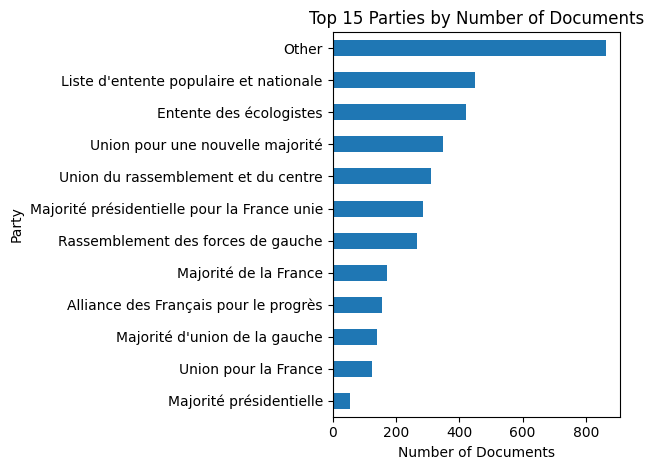

In [102]:
# plot 
party_counts = df_clean["party_clean"].value_counts()

top_n = 15
top_parties = party_counts.head(top_n)

plt.figure()
top_parties.sort_values().plot(kind="barh")

plt.title(f"Top {top_n} Parties by Number of Documents")
plt.xlabel("Number of Documents")
plt.ylabel("Party")

plt.tight_layout()
plt.show()

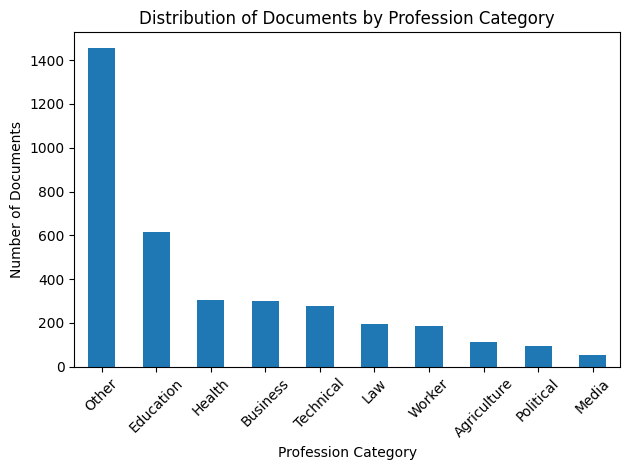

In [103]:
# plot for profession
profession_counts = df_clean["profession_clean"].value_counts()

plt.figure()
profession_counts.plot(kind="bar")
plt.title("Distribution of Documents by Profession Category")
plt.xlabel("Profession Category")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

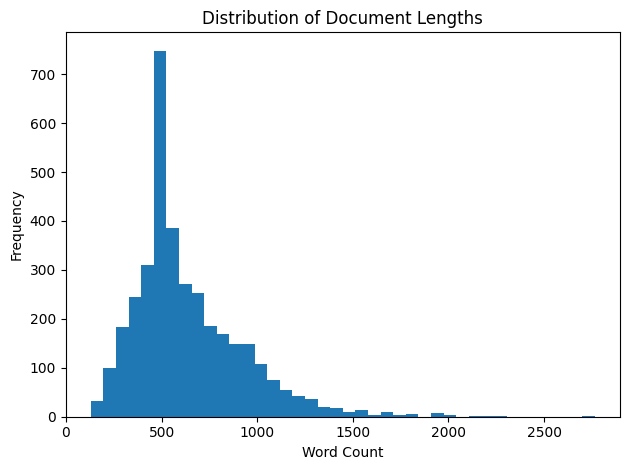

In [104]:
# distibution of docs lengths
plt.figure()
plt.hist(df_clean["word_count"], bins=40)
plt.title("Distribution of Document Lengths")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Lemmatization

In [ ]:
# download spacy model
!python -m spacy download fr_core_news_md

In [ ]:
import spacy

nlp = spacy.load("fr_core_news_md")

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc if not token.is_stop and token.is_alpha])

df_clean["text_lemma"] = df_clean["text"].apply(lemmatize_text)

# 5min

In [106]:
# save data cleaned
df_clean.to_csv("../data/processed/data_cleaned.csv", index=False, encoding="utf-8")